# Investigating trivial and non-trivial contributions to heat

In [ ]:
import os
import dill
import numpy as np
import oqupy
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo
from oqupy.tti_tempo import TTITempoCounting
from scipy.interpolate import interp1d
from oqupy import operators as op
import matplotlib.pyplot as plt

pt_dict={}
folder='results/processtensors'

# System setup


Rho_0=oqupy.operators.spin_dm('x+')

num_params=1
tcut=30
epsrel=10**(-8)

# for TimeDependentSystem
def hamiltonian_t(t):
    return oqupy.operators.sigma("x")/2

# for ParameterisedSystem2ls (NEED 3 PARAMS + no factors of 1/2)
def hamiltonian_param(hx,hy,hz):
    return hx*oqupy.operators.sigma("x") + hy*oqupy.operators.sigma("y") + hz*oqupy.operators.sigma("z")

  0.0%    0 of 5000 [----------------------------------------] 00:01:28

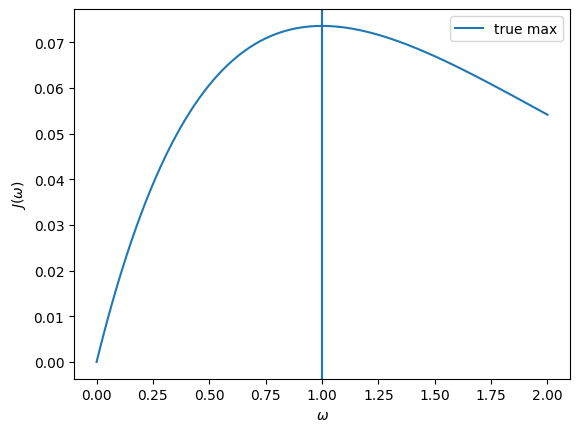

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_31937/2161201246.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/(np.exp(beta*omega)-1)


  2.7%  134 of 5000 [#---------------------------------------] 00:00:10

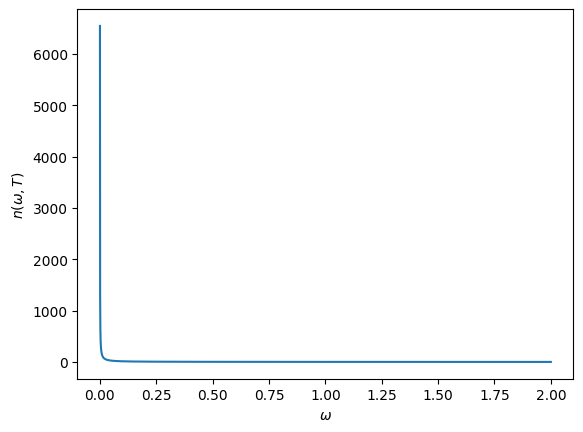

  8.0%  398 of 5000 [###-------------------------------------] 00:02:18[1.00010001]
1
  0.0%    0 of 5000 [----------------------------------------] 00:01:29

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_31937/2161201246.py:37: RuntimeWarning: invalid value encountered in scalar multiply
  mult=bose_vals=[spectral_density(omega,zeta)*bose_einstein(omega,temperature) for omega in omegas]


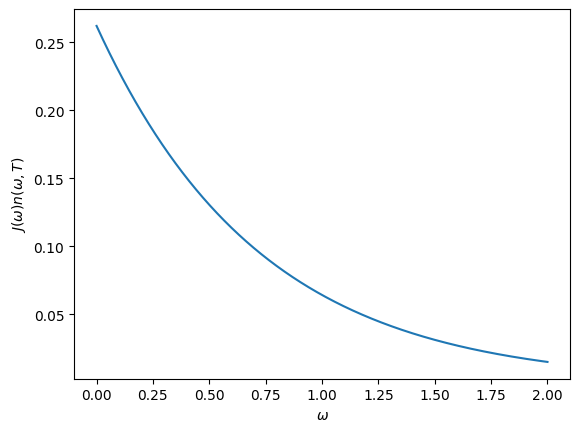

  0.0%    0 of 5000 [----------------------------------------] 00:01:38

In [ ]:
# ohmic spectral density 
alpha=0.1
omega_c=1
zeta=1

# temperature in inverse picoseconds (1K)
temperature=0.131*10

# plotting spectral density and bose-einstein distribution

def spectral_density(omega,zeta):
    return 2*alpha*(omega/omega_c)**zeta *omega_c * np.exp(-omega/omega_c)

omegas=np.linspace(0,2*zeta*omega_c,10000)

density_vals=[spectral_density(omega,zeta) for omega in omegas]
maximum_j = max(density_vals)
pos_max= np.where(density_vals==maximum_j)

plt.plot(omegas,density_vals)
plt.axvline(omegas[pos_max],label='true max')
plt.axvline(zeta*omega_c)
plt.xlabel("$\omega$")
plt.ylabel("$J(\omega)$")
plt.legend()
plt.show()

def bose_einstein(omega,T):
    beta=1/T
    return 1/(np.exp(beta*omega)-1)

bose_vals=[bose_einstein(omega,temperature) for omega in omegas]
plt.plot(omegas,bose_vals)
plt.xlabel("$\omega$")
plt.ylabel("$n(\omega,T)$")
plt.show()
mult=bose_vals=[spectral_density(omega,zeta)*bose_einstein(omega,temperature) for omega in omegas]

plt.plot(omegas,mult)
plt.xlabel("$\omega$")
plt.ylabel("$J(\omega) n(\omega, T)$")
print(omegas[pos_max])
print(zeta*omega_c)

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_31937/2161201246.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/(np.exp(beta*omega)-1)
/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_31937/2450675486.py:2: RuntimeWarning: invalid value encountered in scalar multiply
  return np.pi * alpha * (1+bose_einstein(omega,T)) * spectral_density(omega,zeta)
/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_31937/2450675486.py:5: RuntimeWarning: invalid value encountered in scalar multiply
  return np.pi * alpha * bose_einstein(omega,T) * spectral_density(omega,zeta)


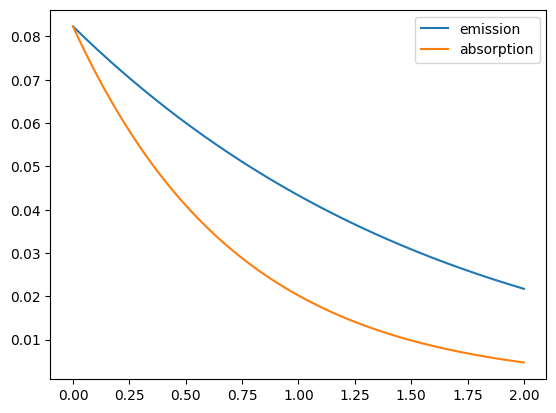

In [58]:
def emission_rate(omega,T,zeta):
    return np.pi * alpha * (1+bose_einstein(omega,T)) * spectral_density(omega,zeta)

def absorption_rate(omega,T,zeta):
    return np.pi * alpha * bose_einstein(omega,T) * spectral_density(omega,zeta)

gamma_d = [emission_rate(omega,temperature,zeta) for omega in omegas]
gamma_u = [absorption_rate(omega,temperature,zeta) for omega in omegas]

plt.plot(omegas,gamma_d,label="emission")
plt.plot(omegas,gamma_u,label="absorption")
plt.legend()
plt.show()

  8.0%  398 of 5000 [###-------------------------------------] 00:02:28(1001,)
  0.0%    0 of 5000 [----------------------------------------] 00:01:39

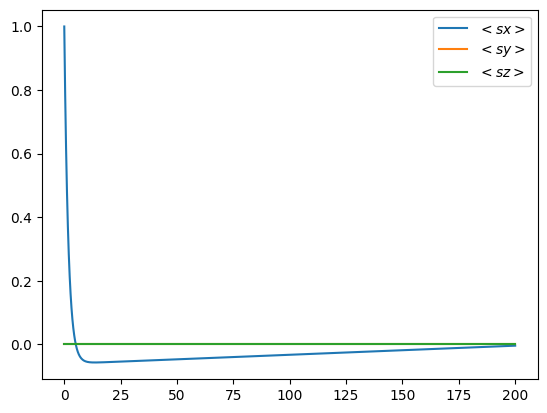

  0.0%    0 of 5000 [----------------------------------------] 00:01:49

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
# looking first at the dynamics due the lindblad relaxation:

# Pauli matrices
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
si = np.eye(2, dtype=complex)

dim=2

# Collapse operators: relaxation and excitation (rotated in sx basis)
sm = sz + 1j*sy
sp = sz - 1j*sy

def solve_lindblad(omega_func, rho0, omega0,t_span, t_eval=None):
    """
    Solve Lindblad equation with time-dependent Hamiltonian.
    H_func(t) should return the Hamiltonian at time t.
    """
    dim = rho0.shape[0]

    def rhs(t, y):
        Ht = omega_func(omega0, t) * sx /2 

        I = np.eye(dim, dtype=complex)
        
        # Hamiltonian contribution
        L_H = -1j * (np.kron(I, Ht) - np.kron(Ht.T, I))
        
        # Time-dependent collapse rates
        gamma_relax_t = emission_rate(omega_func(omega0,t), temperature, zeta)
        gamma_excite_t = absorption_rate(omega_func(omega0,t), temperature, zeta)
        
        # Collapse operators
        L_diss_t = np.zeros((dim*dim, dim*dim), dtype=complex)
        for C, rate in [(sm, gamma_relax_t), (sp, gamma_excite_t)]:
            CdC = C.conj().T @ C
            L_diss_t += rate * np.kron(C.conj(), C)
            L_diss_t += -0.5 * rate * np.kron(I, CdC)
            L_diss_t += -0.5 * rate * np.kron(CdC.T, I)
        
        return (L_H + L_diss_t) @ y
    
    y0 = rho0.reshape(dim*dim, order='F')
    sol = solve_ivp(rhs, t_span, y0, t_eval=t_eval, method='RK45',
                    atol=1e-9, rtol=1e-7)

    rhos = [sol.y[:, i].reshape((dim, dim), order='F')
            for i in range(sol.y.shape[1])]
    return sol.t, rhos

t_max = 200
omega0=omega_c/t_max

# system Hamiltonian definition  H = omega_t * sx /2 
def omega_t(omega0,t):
    return 0.15*(1-t/t_max)+0.01

# num_steps chosen to match those required to resolve dynamics/heats in TEMPO calculation
dt=0.2
num_steps = int(np.round(t_max / dt))

t_eval = np.linspace(0, t_max, num_steps+1)
t, rhos = solve_lindblad(omega_t, Rho_0, omega0,(0, t_max), t_eval=t_eval)
print(t.shape)
# Observables
sx_lind = np.real([np.trace(rho @ sx) for rho in rhos])
sy_lind = np.real([np.trace(rho @ sy) for rho in rhos])
sz_lind = np.real([np.trace(rho @ sz) for rho in rhos])

# Plot
plt.plot(t,sx_lind,label="$<sx>$")
plt.plot(t,sy_lind,label="$<sy>$")
plt.plot(t,sz_lind,label="$<sz>$")
plt.legend()
plt.show()


  2.7%  134 of 5000 [#---------------------------------------] 00:07:271.31
 35.9% 1796 of 5000 [##############--------------------------] 00:08:33

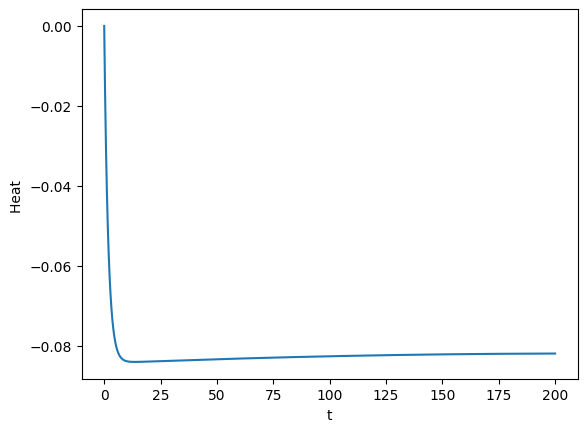

1001


  0.0%    0 of 5000 [----------------------------------------] 00:08:56

In [ ]:
from scipy.integrate import cumulative_trapezoid

def compute_heat(t_points, rhos, omega_func, omega0):
    """Compute heat current Tr(rhodot H) at sampled times."""
    heat_currs = []
    dim = rhos[0].shape[0]

    for ti, rho in zip(t_points, rhos):
        Ht = omega_func(omega0, ti) * sx / 2
        Ht_vec = Ht.reshape(dim*dim, order="F")
        rho_vec = rho.reshape(dim*dim, order="F")

        # Construct Liouvillian at this time
        I = np.eye(dim, dtype=complex)
        L_H = -1j * (np.kron(I, Ht) - np.kron(Ht.T, I))

        gamma_relax_t = emission_rate(omega_func(omega0, ti), temperature, zeta)
        gamma_excite_t = absorption_rate(omega_func(omega0, ti), temperature, zeta)

        L_diss_t = np.zeros((dim*dim, dim*dim), dtype=complex)
        for C, rate in [(sm, gamma_relax_t), (sp, gamma_excite_t)]:
            CdC = C.conj().T @ C
            L_diss_t += rate * np.kron(C.conj(), C)
            L_diss_t += -0.5 * rate * np.kron(I, CdC)
            L_diss_t += -0.5 * rate * np.kron(CdC.T, I)

        L = L_H + L_diss_t

        rhodot = L @ rho_vec
        qdot = np.vdot(Ht_vec, rhodot).real   # ⟨Ht, rhodot⟩
        heat_currs.append(qdot)

    Q = cumulative_trapezoid(heat_currs, t_points, initial=0.0)
    return Q

lindblad_heats = compute_heat(t, rhos, omega_t, omega0)
print(temperature)
plt.plot(t, lindblad_heats)
# opposite sign convention here due to use of weak coupling equation for heat
plt.xlabel("t")
plt.ylabel("Heat ")
plt.show()
print(len(lindblad_heats))


building influence functional:  28%|██▊       | 28/101 [00:00<00:00, 256.96it/s]

building influence functional: 100%|██████████| 101/101 [00:52<00:00,  1.92it/s]


rank  619


building influence functional:  19%|█▉        | 19/101 [00:00<00:00, 189.10it/s]

building influence functional: 100%|██████████| 101/101 [00:59<00:00,  1.69it/s]


...

building influence functional: 100%|██████████| 101/101 [00:00<00:00, 1224.84it/s]


rank  9


building influence functional: 100%|██████████| 101/101 [00:00<00:00, 1065.13it/s]

rank  9
--> Compute dynamics:
  2.6%    3 of  114 [#---------------------------------------] 00:00:00

100.0%  114 of  114 [########################################] 00:00:03
Elapsed time: 3.9s
--> Compute dynamics:
100.0%  114 of  114 [########################################] 00:00:03
Elapsed time: 3.8s


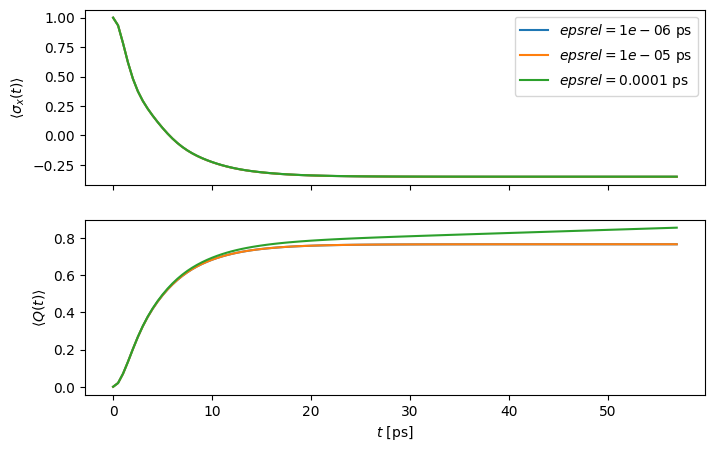

In [8]:
# process tensor intiialisation (pre-computed)
# generated using previous code (without analytic propagators)
epsrel=10**(-8)
tcut=50
u=0.01
dt=0.5

fig, axs = plt.subplots(2, figsize=(8, 5), sharex=True)
for epsrel in [10**(-6),10**(-5),10**(-4)]:

        # spectral density (without cutoff)
    def j(w):
        return 2*alpha*w

    correlations = oqupy.PowerLawSD(alpha=alpha,
                                    zeta=1,
                                    cutoff=omega_c,
                                    cutoff_type='exponential',
                                    temperature=temperature)
    bath = oqupy.Bath(op.sigma("z")/2.0, correlations)
    parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=int(tcut/dt)+1)

    u=0.01
    correlationscf=oqupy.bath_correlations.CustomCountingSD(j_function=j,cutoff=omega_c,u=u,
                                                    cutoff_type='exponential',temperature=temperature)

    bathcf = oqupy.Bath(op.sigma("z")/2.0, correlationscf)

    #num_steps=int(t_arg/dt)

    pt_= TTITempo(bath,start_time=0.0,parameters=parameters)
    pt= pt_.get_process_tensor()

    pt_cf=TTITempoCounting(bathcf,start_time=0.0,parameters=parameters)
    ptcf = pt_cf.get_process_tensor()
    system = oqupy.TimeDependentSystem(hamiltonian_t)

    num_steps = int(np.round(t_max / dt))

    dynamics = oqupy.compute_dynamics(
        process_tensor=pt,
        system=system,
        initial_state=Rho_0,
        start_time=0,
        num_steps=num_steps)

    dynamicscf = oqupy.compute_dynamics(
        process_tensor=ptcf,
        system=system,
        initial_state=Rho_0,
        start_time=0,
        num_steps=num_steps)
    
    t,final_x = dynamics.expectations(op.sigma('x'), real=True)
    final_Q = dynamicscf.states.trace(axis1=1, axis2=2).imag / 0.01
    axs[0].plot(t,final_x,'-',label=r'$epsrel={0}$ ps'.format(epsrel))
    axs[1].plot(t,final_Q,'-')

    axs[0].legend()
    axs[0].set_ylabel(r'$\langle \sigma_x (t) \rangle$')
    axs[1].set_ylabel(r'$\langle Q (t) \rangle$')
    axs[1].set_xlabel(r'$ t$ [ps]')

plt.show()


building influence functional: 100%|██████████| 101/101 [00:00<00:00, 1348.61it/s]


rank  9


building influence functional: 100%|██████████| 101/101 [00:00<00:00, 1317.94it/s]

rank  9
--> Compute dynamics:
  2.6%    3 of  114 [#---------------------------------------] 00:00:00

100.0%  114 of  114 [########################################] 00:00:04
Elapsed time: 4.1s
--> Compute dynamics:
100.0%  114 of  114 [########################################] 00:00:04
Elapsed time: 4.0s


...

building influence functional: 100%|██████████| 21/21 [00:00<00:00, 238.03it/s]


rank  41


building influence functional: 100%|██████████| 21/21 [00:00<00:00, 184.84it/s]

rank  42
--> Compute dynamics:
  0.9%    1 of  114 [----------------------------------------] 00:00:00

100.0%  114 of  114 [########################################] 00:00:05
Elapsed time: 5.1s
--> Compute dynamics:
100.0%  114 of  114 [########################################] 00:00:04
Elapsed time: 4.6s


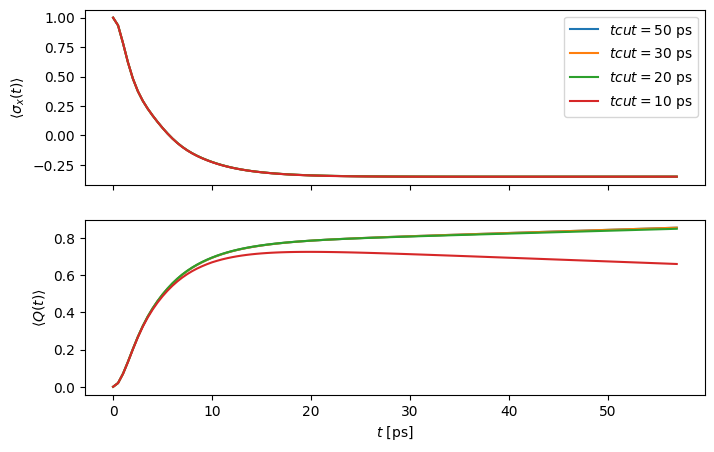

In [13]:
epresl=10**(-5)
fig, axs = plt.subplots(2, figsize=(8, 5), sharex=True)
for tcut in [50,30,20,10]:

        # spectral density (without cutoff)
    def j(w):
        return 2*alpha*w

    correlations = oqupy.PowerLawSD(alpha=alpha,
                                    zeta=1,
                                    cutoff=omega_c,
                                    cutoff_type='exponential',
                                    temperature=temperature)
    bath = oqupy.Bath(op.sigma("z")/2.0, correlations)
    parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=int(tcut/dt)+1)

    u=0.01
    correlationscf=oqupy.bath_correlations.CustomCountingSD(j_function=j,cutoff=omega_c,u=u,
                                                    cutoff_type='exponential',temperature=temperature)

    bathcf = oqupy.Bath(op.sigma("z")/2.0, correlationscf)

    #num_steps=int(t_arg/dt)

    pt_= TTITempo(bath,start_time=0.0,parameters=parameters)
    pt= pt_.get_process_tensor()

    pt_cf=TTITempoCounting(bathcf,start_time=0.0,parameters=parameters)
    ptcf = pt_cf.get_process_tensor()
    system = oqupy.TimeDependentSystem(hamiltonian_t)

    num_steps = int(np.round(t_max / dt))

    dynamics = oqupy.compute_dynamics(
        process_tensor=pt,
        system=system,
        initial_state=Rho_0,
        start_time=0,
        num_steps=num_steps)

    dynamicscf = oqupy.compute_dynamics(
        process_tensor=ptcf,
        system=system,
        initial_state=Rho_0,
        start_time=0,
        num_steps=num_steps)
    
    t,final_x = dynamics.expectations(op.sigma('x'), real=True)
    final_Q = dynamicscf.states.trace(axis1=1, axis2=2).imag / 0.01
    axs[0].plot(t,final_x,'-',label=r'$tcut={0}$ ps'.format(tcut))
    axs[1].plot(t,final_Q,'-')

    axs[0].legend()
    axs[0].set_ylabel(r'$\langle \sigma_x (t) \rangle$')
    axs[1].set_ylabel(r'$\langle Q (t) \rangle$')
    axs[1].set_xlabel(r'$ t$ [ps]')

plt.show()

building influence functional: 100%|██████████| 151/151 [00:00<00:00, 1132.80it/s]


rank  6


building influence functional: 100%|██████████| 151/151 [00:00<00:00, 930.18it/s] 

rank  6
--> Compute dynamics:
  0.3%    1 of  286 [----------------------------------------] 00:00:00

100.0%  286 of  286 [########################################] 00:00:10
Elapsed time: 11.0s
--> Compute dynamics:
100.0%  286 of  286 [########################################] 00:00:10
Elapsed time: 10.3s


...

building influence functional: 100%|██████████| 61/61 [00:00<00:00, 1179.79it/s]


rank  9


building influence functional: 100%|██████████| 61/61 [00:00<00:00, 1147.33it/s]

rank  9
--> Compute dynamics:
  2.6%    3 of  114 [#---------------------------------------] 00:00:00

100.0%  114 of  114 [########################################] 00:00:04
Elapsed time: 4.1s
--> Compute dynamics:
100.0%  114 of  114 [########################################] 00:00:04
Elapsed time: 4.1s


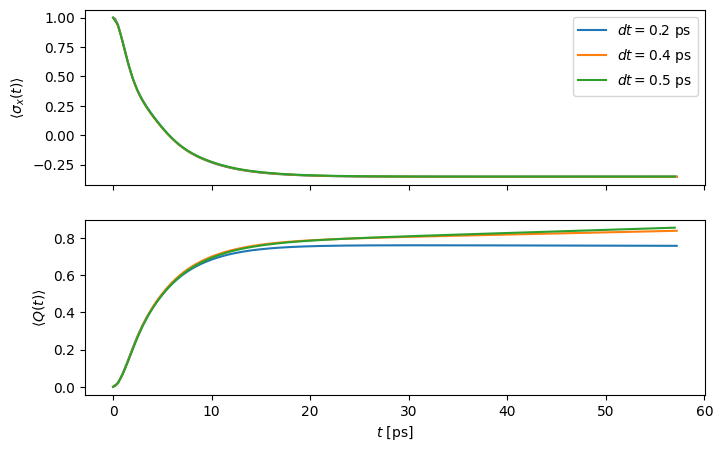

In [15]:
epresl=10**(-6)
tcut=30
fig, axs = plt.subplots(2, figsize=(8, 5), sharex=True)
for dt in [0.2,0.4,0.5]:

        # spectral density (without cutoff)
    def j(w):
        return 2*alpha*w

    correlations = oqupy.PowerLawSD(alpha=alpha,
                                    zeta=1,
                                    cutoff=omega_c,
                                    cutoff_type='exponential',
                                    temperature=temperature)
    bath = oqupy.Bath(op.sigma("z")/2.0, correlations)
    parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=int(tcut/dt)+1)

    u=0.01
    correlationscf=oqupy.bath_correlations.CustomCountingSD(j_function=j,cutoff=omega_c,u=u,
                                                    cutoff_type='exponential',temperature=temperature)

    bathcf = oqupy.Bath(op.sigma("z")/2.0, correlationscf)

    #num_steps=int(t_arg/dt)

    pt_= TTITempo(bath,start_time=0.0,parameters=parameters)
    pt= pt_.get_process_tensor()

    pt_cf=TTITempoCounting(bathcf,start_time=0.0,parameters=parameters)
    ptcf = pt_cf.get_process_tensor()
    system = oqupy.TimeDependentSystem(hamiltonian_t)

    num_steps = int(np.round(t_max / dt))

    dynamics = oqupy.compute_dynamics(
        process_tensor=pt,
        system=system,
        initial_state=Rho_0,
        start_time=0,
        num_steps=num_steps)

    dynamicscf = oqupy.compute_dynamics(
        process_tensor=ptcf,
        system=system,
        initial_state=Rho_0,
        start_time=0,
        num_steps=num_steps)
    
    t,final_x = dynamics.expectations(op.sigma('x'), real=True)
    final_Q = dynamicscf.states.trace(axis1=1, axis2=2).imag / 0.01
    axs[0].plot(t,final_x,'-',label=r'$dt={0}$ ps'.format(dt))
    axs[1].plot(t,final_Q,'-')

    axs[0].legend()
    axs[0].set_ylabel(r'$\langle \sigma_x (t) \rangle$')
    axs[1].set_ylabel(r'$\langle Q (t) \rangle$')
    axs[1].set_xlabel(r'$ t$ [ps]')

plt.show()

In [30]:
dt=0.2
tcut=60
epsrel=10**(-6)


parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=int(tcut/dt)+1)

pt_= TTITempo(bath,start_time=0.0,parameters=parameters)
pt= pt_.get_process_tensor()

pt_cf=TTITempoCounting(bathcf,start_time=0.0,parameters=parameters)
ptcf = pt_cf.get_process_tensor()

building influence functional:   9%|▉         | 27/301 [00:00<00:01, 251.49it/s]

building influence functional: 100%|██████████| 301/301 [1:10:16<00:00, 14.01s/it]     


rank  864


/Users/eoinoneill/Desktop/OQuPy/oqupy/bath_correlations.py:1165: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  im_int += integrate.quad(im_integrand,
/Users/eoinoneill/Desktop/OQuPy/oqupy/bath_correlations.py:1160: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  re_int += integrate.quad(re_integrand,
building influence functional:   7%|▋         | 20/301 [00:00<00:01, 197.18it/s]

building influence functional: 100%|██████████| 301/301 [08:32<00:00,  1.70s/it]


rank  867


In [64]:
epsrel=10**(-6)
file_name1='results/processtensors_10K/processtensor_dt={0}_ps=-{1}_tcut={2}'.format(dt,-np.round(np.log10(epsrel),1),tcut)
with open(file_name1,'rb') as f:
    pt=dill.load(f)

file_name1='results/processtensors_10K/processtensorCF_dt={0}_ps=-{1}_tcut={2}'.format(dt,-np.round(np.log10(epsrel),1),tcut)
with open(file_name1,'rb') as f:
    ptcf=dill.load(f)

In [65]:
# system definition
#system = oqupy.TimeDependentSystem(hamiltonian_t)
system=oqupy.ParameterizedSystem2ls(hamiltonian_param)

--> Compute forward propagation:
100.0% 1000 of 1000 [########################################] 00:00:31
Elapsed time: 31.0s
--> Compute backward propagation:
100.0% 1000 of 1000 [########################################] 00:00:38
Elapsed time: 38.2s
--> Apply chain rule:
100.0% 1000 of 1000 [########################################] 00:00:09
Elapsed time: 9.5s
  0.0%    0 of 5000 [----------------------------------------] 00:03:08

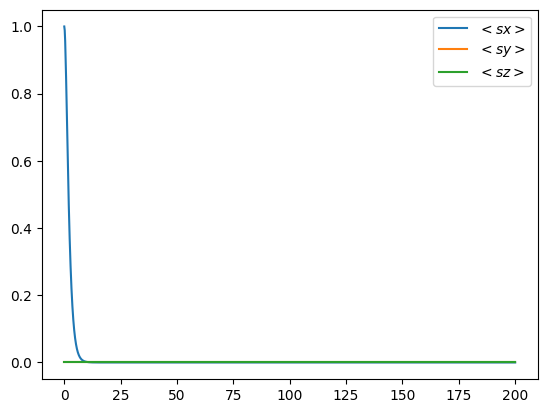

In [75]:
# now looking at the contribution due to the pure dephasing in independent boson model (for an Ohmic bath)
num_steps = int(np.round(t_max / dt))

hx_zeros=np.ones(2*num_steps)*0.000005
hy_zeros=np.zeros(2*num_steps)
hz_zeros=np.zeros(2*num_steps)

param_list=np.vstack((hx_zeros,hy_zeros,hz_zeros)).T

grad_IBM=oqupy.state_gradient(
    process_tensors=[pt],
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps,
    parameters=param_list,
    target_derivative=op.spin_dm('mixed').T
)

dynamics_IBM = grad_IBM['dynamics']

def IBM_heat_ohmic(t):
    return (alpha*omega_c**3 * t**2 )/(1+ omega_c**3 * t**2)

t_list=np.linspace(0,t_max,len(dynamics_IBM.states))

sx_IBM = np.real([np.trace(rho @ sx) for rho in dynamics_IBM.states])
sy_IBM = np.real([np.trace(rho @ sy) for rho in dynamics_IBM.states])
sz_IBM = np.real([np.trace(rho @ sz) for rho in dynamics_IBM.states])
# Plot
plt.plot(t,sx_IBM,label="$<sx>$")
plt.plot(t,sy_IBM,label="$<sy>$")
plt.plot(t,sz_IBM,label="$<sz>$")
plt.legend()
plt.show()



In [77]:
#hx_zeros=np.ones(2*num_steps)*0.0001
h_max = 0.15      # initial Hamiltonian splitting
h_min = 0.01      # final splitting
u=0.01

# Linear ramp
hx = np.linspace(h_max, h_min, 2*num_steps)
param_list=np.vstack((hx,hy_zeros,hz_zeros)).T

grad=oqupy.state_gradient(
    process_tensors=[pt],
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps,
    parameters=param_list,
    target_derivative=op.spin_dm('mixed').T
)

gradcf=oqupy.state_gradient(
process_tensors=[ptcf],
system=system,
initial_state=Rho_0,
start_time=0,
num_steps=num_steps,
parameters=param_list,
target_derivative=-1j*np.identity(2)/u
)


--> Compute forward propagation:
100.0% 1000 of 1000 [########################################] 00:00:35
Elapsed time: 35.0s
--> Compute backward propagation:
100.0% 1000 of 1000 [########################################] 00:00:42
Elapsed time: 42.7s
--> Apply chain rule:
100.0% 1000 of 1000 [########################################] 00:00:08
Elapsed time: 8.3s
--> Compute forward propagation:
100.0% 1000 of 1000 [########################################] 00:00:37
Elapsed time: 37.9s
--> Compute backward propagation:
100.0% 1000 of 1000 [########################################] 00:00:40
Elapsed time: 40.1s
--> Apply chain rule:
100.0% 1000 of 1000 [########################################] 00:00:07
Elapsed time: 7.0s


Text(0.5, 0, '$ t$ [ps]')

 35.9% 1796 of 5000 [##############--------------------------] 00:08:44

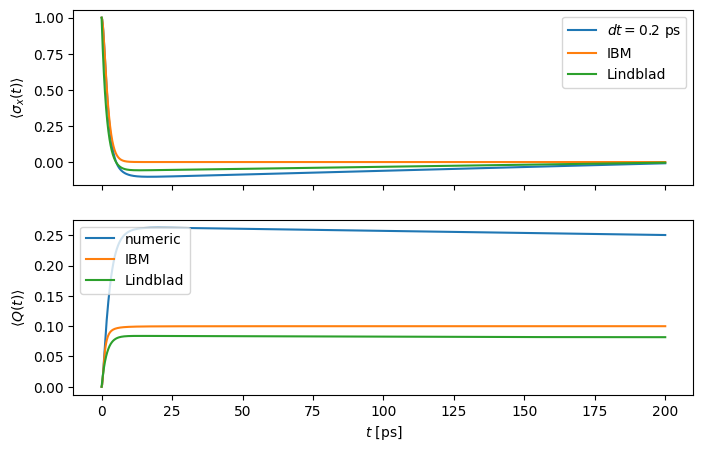

 35.9% 1796 of 5000 [##############--------------------------] 00:12:38

In [ ]:
fig, axs = plt.subplots(2, figsize=(8, 5), sharex=True)
dynamics=grad['dynamics']
dynamicscf=gradcf['dynamics']

t,final_x = dynamics.expectations(op.sigma('x'), real=True)
final_Q = dynamicscf.states.trace(axis1=1, axis2=2).imag / u
axs[0].plot(t,final_x,'-',label=r'$dt={0}$ ps'.format(dt))
axs[0].plot(t,sx_IBM, label='IBM')
axs[0].plot(t,sx_lind,label='Lindblad')

axs[1].plot(t,final_Q,'-',label='numeric')
axs[1].plot(t,IBM_heat_ohmic(t),label='IBM')
# (reverse sign to match convention)
axs[1].plot(t,-lindblad_heats,label='Lindblad')

axs[0].legend()
axs[1].legend()

axs[0].set_ylabel(r'$\langle \sigma_x (t) \rangle$')
axs[1].set_ylabel(r'$\langle Q (t) \rangle$')
axs[1].set_xlabel(r'$ t$ [ps]')

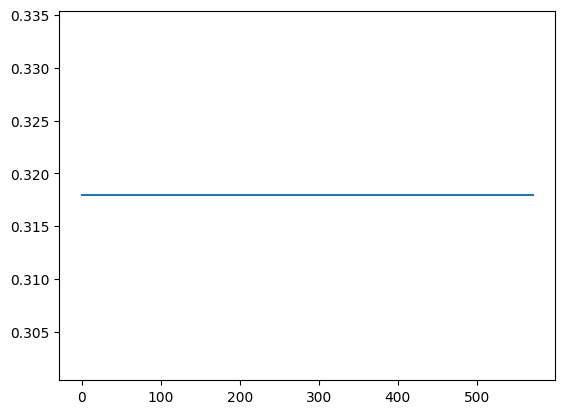

 15.4%   44 of  286 [######----------------------------------] 01:59:09

In [ ]:
plt.plot(hx*(1-np.tanh(hx/temperature)))

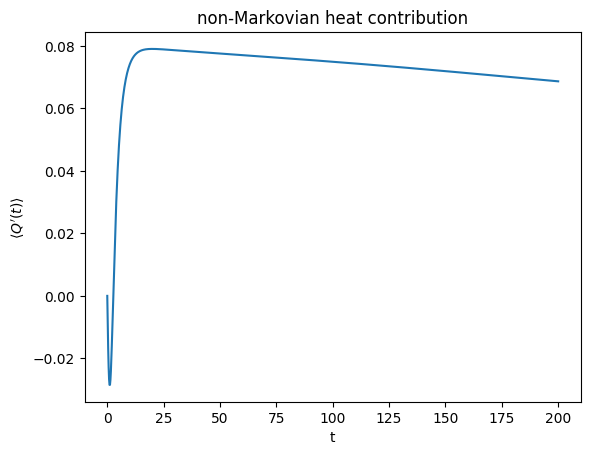

  2.7%  134 of 5000 [#---------------------------------------] 00:11:33

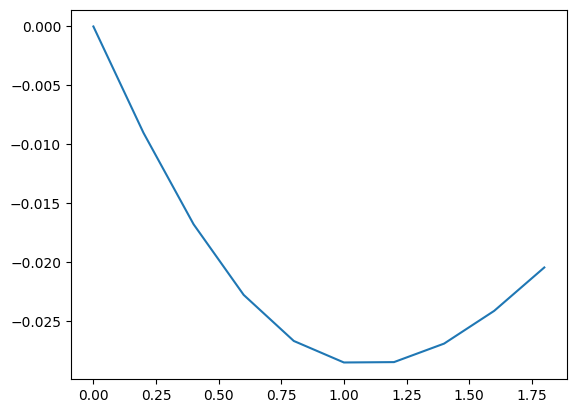

 35.9% 1796 of 5000 [##############--------------------------] 01:10:02

In [ ]:
plt.plot(t,final_Q+lindblad_heats-IBM_heat_ohmic(t))
plt.xlabel("t")
plt.ylabel(r"$ \langle Q'(t) \rangle $ ")
plt.title("non-Markovian heat contribution")
plt.show()
snippet=10
plt.plot(t[:snippet],final_Q[:snippet]+lindblad_heats[:snippet]-IBM_heat_ohmic(t[:snippet]))
plt.show()

  9.2%   37 of  400 [###-------------------------------------] 03:01:33

<Axes: >

 65.0%   93 of  143 [##########################--------------] 00:17:47

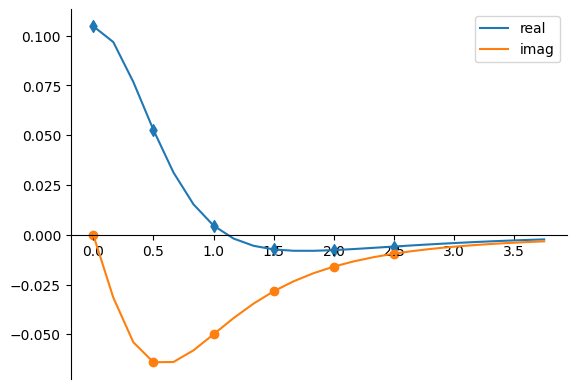

In [ ]:
correlations = oqupy.PowerLawSD(alpha=0.05,
                                zeta=1,
                                cutoff=1,
                                cutoff_type='exponential',
                                temperature=0.131)
sigma_z = oqupy.operators.sigma("z")
bath = oqupy.Bath(0.5 * sigma_z, correlations)

fig, ax = plt.subplots()
params = oqupy.TempoParameters(dt=0.5, epsrel=1, tcut=2.5) # N.B. epsrel not used by helper, and tcut only to set plot t-limits
oqupy.helpers.plot_correlations_with_parameters(bath.correlations, params, ax=ax)

  8.0%  398 of 5000 [###-------------------------------------] 02:04:57

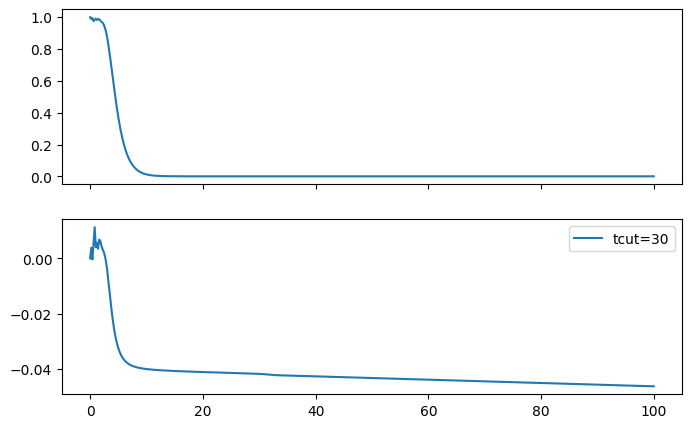

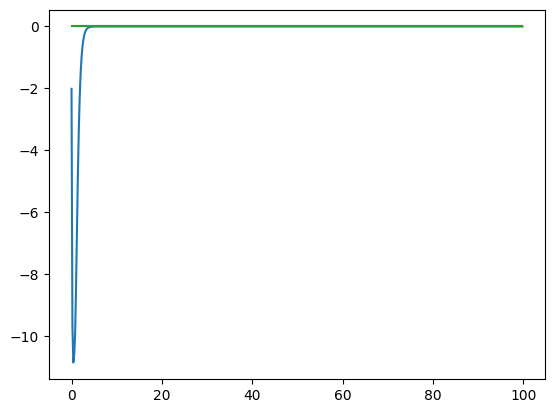

  8.0%  398 of 5000 [###-------------------------------------] 02:04:58

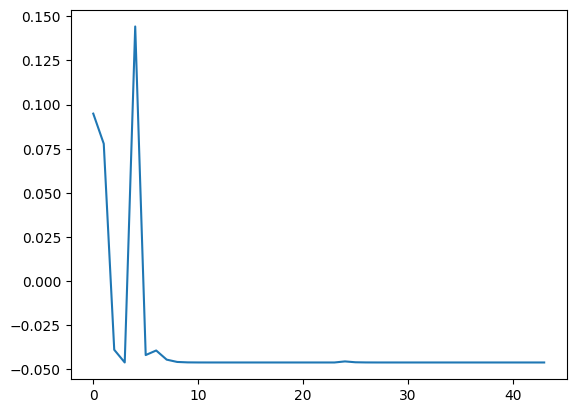

  8.0%  398 of 5000 [###-------------------------------------] 02:06:35

In [ ]:
fig,axs = plt.subplots(2, figsize=(8, 5), sharex=True)
final_time=100

file_name1='results/zero_control_10K_1param/dt=0.2_ps=-6.0_tcut=30_T=10K_nonzero/{0}ps'.format(final_time)

with open(file_name1,'rb') as f:
    opt_dict=dill.load(f)


t,sx=opt_dict['fidelitygrad']['dynamics'].expectations(op.sigma('x'),real=True)
axs[0].plot(t,sx,label='tcut={0}'.format(tcut))

axs[1].plot(t,opt_dict['log'][-1]['full heats'],label='tcut={0}'.format(tcut))
plt.legend()
plt.show()
controlx = opt_dict['result'].x[0::3]
controly = opt_dict['result'].x[1::3]
controlz = opt_dict['result'].x[2::3]
plt.plot(t[:-1],controlx)
plt.plot(t[:-1],controly)
plt.plot(t[:-1],controlz)
plt.show()

num_iterations=np.shape(opt_dict['log'])[0]
final_heats= [opt_dict['log'][i]['final heat'] for i in range(0,num_iterations)]
plt.plot(final_heats)




FileNotFoundError: [Errno 2] No such file or directory: 'results/processtensors/processtensorCF_dt=0.7_ps=-6.0_tcut=5_alpha=0.05'

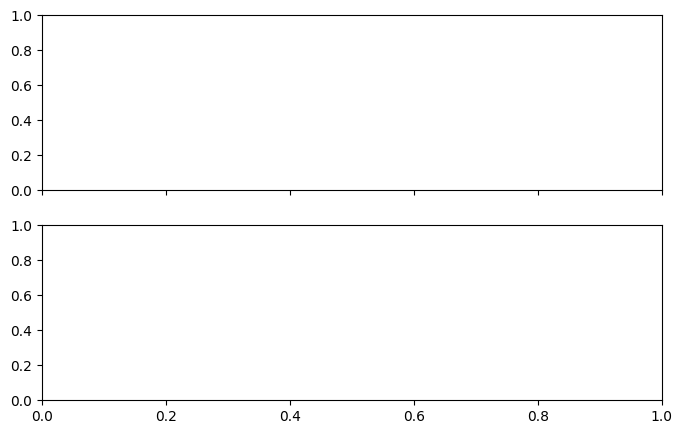

In [ ]:
dt=0.7
epsrel=10**(-6)
fig, axs = plt.subplots(2, figsize=(8, 5), sharex=True)
for tcut in [5,10,20,30]:
    file_name1=os.path.join(folder,'processtensor_dt={0}_ps={1}_tcut={2}_alpha=0.05'.format(dt,np.round(np.log10(epsrel),1),tcut))
    with open(file_name1,'rb') as f:
        pt=dill.load(f)


    file_name1=os.path.join(folder,'processtensorCF_dt={0}_ps={1}_tcut={2}_alpha=0.05'.format(dt,np.round(np.log10(epsrel),1),tcut))
    with open(file_name1,'rb') as f:
        ptcf=dill.load(f)
    system = oqupy.TimeDependentSystem(hamiltonian_t)

    num_steps = int(np.round(t_prot / dt))

    dynamics = oqupy.compute_dynamics(
        process_tensor=pt,
        system=system,
        initial_state=Rho_0,
        start_time=0,
        num_steps=num_steps)

    dynamicscf = oqupy.compute_dynamics(
        process_tensor=ptcf,
        system=system,
        initial_state=Rho_0,
        start_time=0,
        num_steps=num_steps)
    
    final_x = dynamics.expectations(op.sigma('x'), real=True)[1]
    final_Q = dynamicscf.states.trace(axis1=1, axis2=2).imag / 0.01
    axs[0].plot(np.linspace(0,t_prot,len(final_x)),final_x,'-',label=r'$tcut={0}$ ps'.format(tcut))
    axs[1].plot(np.linspace(0,t_prot,len(final_x)),final_Q,'-')

    axs[0].legend()
    axs[0].set_ylabel(r'$\langle \sigma_x (t) \rangle$')
    axs[1].set_ylabel(r'$\langle Q (t) \rangle$')
    axs[1].set_xlabel(r'$ t$ [ps]')

plt.show()

In [ ]:
tcut=20
epsrel=10**(-6)
dt=0.7

file_name1='results/zero_control_lowercoupling/500ps/optimization_simplemodel_500ps'
with open(file_name1,'rb') as f:
    opt_dict=dill.load(f)

opt_dict['opttime'][0]/60

29.978314832846323

 46.2%  132 of  286 [##################----------------------] 00:34:37

--> Compute dynamics:
100.0%  286 of  286 [########################################] 00:00:11
Elapsed time: 11.6s
--> Compute dynamics:
100.0%  286 of  286 [########################################] 00:00:09
Elapsed time: 9.3s
--> Compute dynamics:
100.0%  286 of  286 [########################################] 00:00:14
Elapsed time: 14.5s
--> Compute dynamics:
100.0%  286 of  286 [########################################] 00:00:19
Elapsed time: 19.9s


/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_83258/4128498049.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


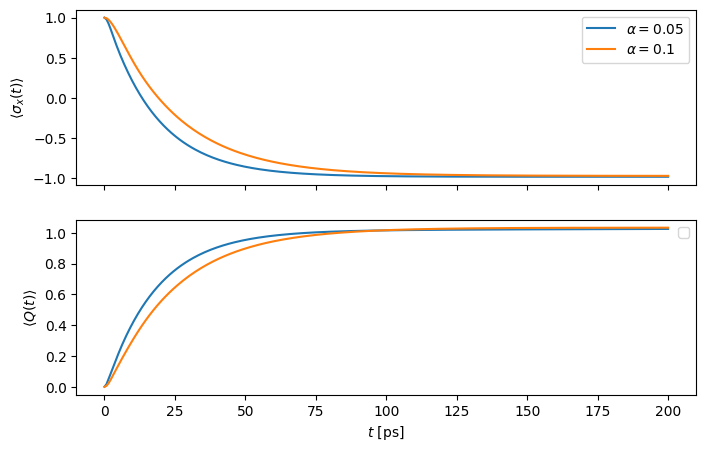

In [ ]:
dt=0.7
epsrel=10**(-6)
tcut=20
fig, axs = plt.subplots(2, figsize=(8, 5), sharex=True)
t_prot=200
folder='results/processtensors_lowercoupling'
file_name1=os.path.join(folder,'processtensor_dt={0}_ps={1}_tcut={2}_alpha=0.05'.format(dt,np.round(np.log10(epsrel),1),tcut))
with open(file_name1,'rb') as f:
    pt_05=dill.load(f)

file_name1=os.path.join(folder,'processtensorCF_dt={0}_ps={1}_tcut={2}_alpha=0.05'.format(dt,np.round(np.log10(epsrel),1),tcut))
with open(file_name1,'rb') as f:
    ptcf_05=dill.load(f)

folder='results/processtensors'
# larger coupling, dt=0.25 , tcut=30 , epsrel=7
file_name1=os.path.join(folder,'processtensor_dt={0}_ps={1}_tcut={2}'.format(0.25,np.round(np.log10(10**(-7)),1),30))
with open(file_name1,'rb') as f:
    pt_1=dill.load(f)

file_name1=os.path.join(folder,'processtensorCF_dt={0}_ps={1}_tcut={2}'.format(0.25,np.round(np.log10(10**(-7)),1),30))
with open(file_name1,'rb') as f:
    ptcf_1=dill.load(f)

system = oqupy.TimeDependentSystem(hamiltonian_t)

num_steps = int(np.round(t_prot / dt))

dynamics_05 = oqupy.compute_dynamics(
    process_tensor=pt_05,
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps)

dynamicscf_05 = oqupy.compute_dynamics(
    process_tensor=ptcf_05,
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps)

dynamics_1 = oqupy.compute_dynamics(
    process_tensor=pt_1,
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps)

dynamicscf_1 = oqupy.compute_dynamics(
    process_tensor=ptcf_1,
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps)

final_x = dynamics_05.expectations(op.sigma('x'), real=True)[1]
final_Q = dynamicscf_05.states.trace(axis1=1, axis2=2).imag / 0.01
axs[0].plot(np.linspace(0,t_prot,len(final_x)),final_x,'-',label=r'$\alpha=0.05$')
axs[1].plot(np.linspace(0,t_prot,len(final_x)),final_Q,'-')

final_x = dynamics_1.expectations(op.sigma('x'), real=True)[1]
final_Q = dynamicscf_1.states.trace(axis1=1, axis2=2).imag / 0.01
axs[0].plot(np.linspace(0,t_prot,len(final_x)),final_x,'-',label=r'$\alpha=0.1$')
axs[1].plot(np.linspace(0,t_prot,len(final_x)),final_Q,'-')

axs[0].legend()
axs[0].set_ylabel(r'$\langle \sigma_x (t) \rangle$')
axs[1].set_ylabel(r'$\langle Q (t) \rangle$')
axs[1].set_xlabel(r'$ t$ [ps]')
plt.legend()
plt.show()
folder='results/processtensors_lowercoupling'

In [ ]:
import os 
# dt=0.7 eps=10**(-6) tcut=20ps
file_name1='results/zero_control_lowercoupling/500ps/optimization_simplemodel_500ps'
with open(file_name1,'rb') as f:
    opt_dict=dill.load(f)

file_name1='results/opt_convergence_lowercoupling/dt=0.7ps_eps=-6.0_tcut=20/500ps'
with open(file_name1,'rb') as f:
    opt_dict01=dill.load(f)

file_name1='results/opt_convergence_lowercoupling/dt=0.7ps_eps=-8.0_tcut=30/500ps'
with open(file_name1,'rb') as f:
    opt_dict02=dill.load(f)

file_name1='results/opt_convergence_lowercoupling/dt=0.7ps_eps=-9.0_tcut=30/500ps'
with open(file_name1,'rb') as f:
    opt_dict03=dill.load(f)

file_name1='results/zero_control_lowercoupling/500ps/optimization_simplemodel_500ps'
with open(file_name1,'rb') as f:
    opt_dict=dill.load(f)

# dt=0.5 eps=10**(-7)  tcut=30
file_name1='results/opt_convergence_lowercoupling/dt=0.5ps_eps=-7.0_tcut=30/500ps'
with open(file_name1,'rb') as f:
    opt_dict2=dill.load(f)

file_name1='results/opt_convergence_lowercoupling/dt=0.5ps_eps=-8.0_tcut=30/500ps'
with open(file_name1,'rb') as f:
    opt_dict3=dill.load(f)

 46.2%  132 of  286 [##################----------------------] 00:36:01

In [ ]:
# varying epsrel

t1,sx1=opt_dict['fidelitygrad']['dynamics'].expectations(op.sigma('x'), real=True)

plt.plot(t1[:-1],opt_dict['result'].x)
plt.show()

t2,sx2=opt_dict2['dynamics'].expectations(op.sigma('x'),real=True)
t3,sx3=opt_dict2['dynamics'].expectations(op.sigma('x'),real=True)
t01,sx01=opt_dict01['dynamics'].expectations(op.sigma('x'),real=True)
t02,sx02=opt_dict02['dynamics'].expectations(op.sigma('x'),real=True)
t03,sx03=opt_dict03['dynamics'].expectations(op.sigma('x'),real=True)
plt.plot(t1,sx1)
plt.plot(t2,sx2)
plt.plot(t2,sx3)
plt.plot(t01,sx01)
plt.plot(t02,sx02,label='eps=-8.0')
plt.plot(t03,sx03,label='eps=-8.0')
plt.legend()
plt.show()

plt.plot(t1,opt_dict['log'][-1]['full heats'])
plt.plot(t2,opt_dict2['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label='2')
plt.plot(t2,opt_dict3['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label='3')
plt.plot(t01,opt_dict01['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label='epsrel=-6')
plt.plot(t02,opt_dict02['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label='epsrel=-8')
plt.plot(t03,opt_dict03['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label='sprel=-9')
print(len(t1))

plt.legend()
plt.show()



KeyError: 'fidelitygrad'

 46.2%  132 of  286 [##################----------------------] 00:34:36

  0.0%    0 of  143 [----------------------------------------] 06:47:43

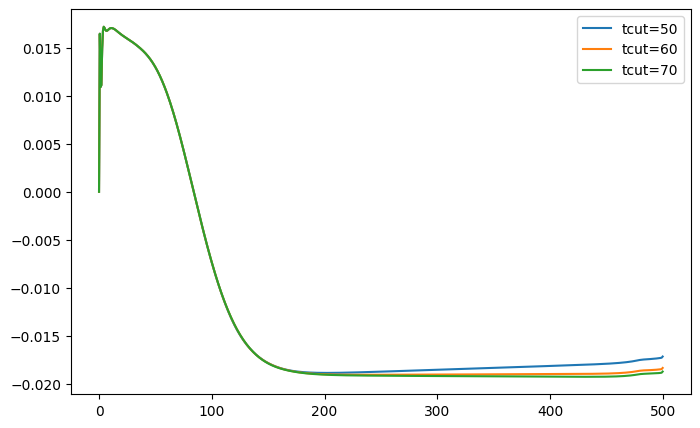

  0.0%    0 of  143 [----------------------------------------] 06:51:31

In [ ]:
# varytcut 
fig,axs = plt.subplots(1, figsize=(8, 5), sharex=True)
for tcut in [50,60,70]:
    file_name1='results/opt_convergence_lowercoupling/dt=0.7ps_eps=-8.0_tcut={0}/500ps'.format(tcut)
    with open(file_name1,'rb') as f:
        opt_dict=dill.load(f)

    t,sx=opt_dict['dynamics'].expectations(op.sigma('x'),real=True)
    #axs[0].plot(t,sx,label='tcut={0}'.format(tcut))

    axs.plot(t,opt_dict['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label='tcut={0}'.format(tcut))
    plt.legend()



715
  0.0%    0 of  143 [----------------------------------------] 06:47:44

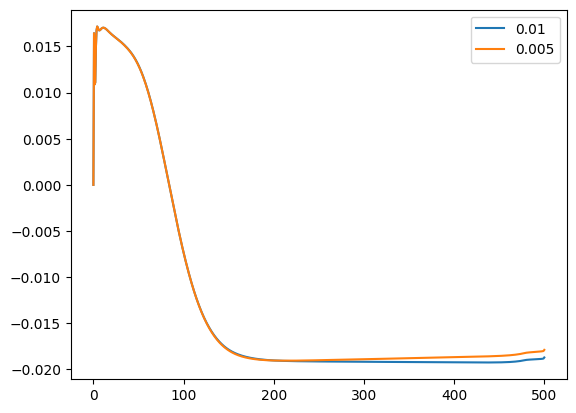

  0.0%    0 of  143 [----------------------------------------] 06:51:46

In [ ]:
file_name1='results/opt_convergence_lowercoupling/dt=0.7ps_eps=-8.0_tcut=70/500ps'.format(tcut)
with open(file_name1,'rb') as f:
    opt_dict=dill.load(f)

file_name1='results/opt_convergence_lowercoupling/dt=0.7ps_eps=-8.0_tcut=70_u=0.005/500ps'.format(tcut)
with open(file_name1,'rb') as f:
    opt_dict2=dill.load(f)

t,sx=opt_dict['dynamics'].expectations(op.sigma('x'),real=True)
print(len(t))
plt.plot(t,opt_dict['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label='0.01')
plt.plot(t,opt_dict2['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.005,label='0.005')
plt.legend()
plt.show()

  0.0%    0 of  143 [----------------------------------------] 06:51:47

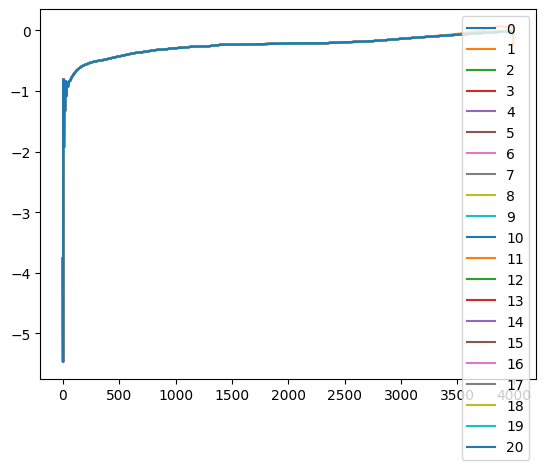

  0.0%    0 of  143 [----------------------------------------] 06:51:59

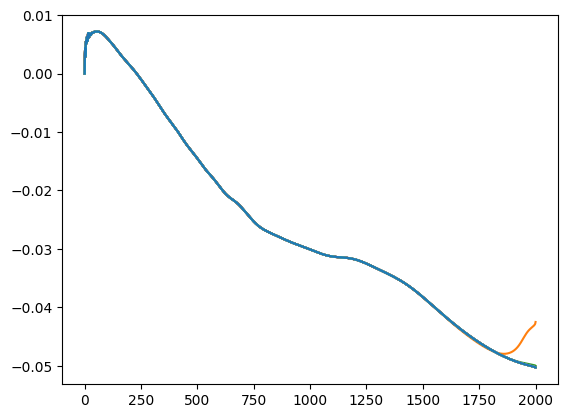

{'epsrel': 1e-08, 'alpha': 0.05, 'omega_cutoff': 1, 'temp': 0.131, 'dt': 0.25, 'tcut': 30}


  0.0%    0 of  143 [----------------------------------------] 07:20:40

In [ ]:
file_name1='results/zero_control_lowercoupling/dt=0.25_ps=-8.0_tcut=30_alpha=0.05/500ps'
#file_name1='results/zero_control_lowercoupling/500ps/optimization_simplemodel_500ps'
with open(file_name1,'rb') as f:
    opt_dict=dill.load(f)

for i in range(len(opt_dict['log'])):
    plt.plot(opt_dict['log'][i]['x'],label='{0}'.format(i))
plt.legend()
plt.show()
for i in range(len(opt_dict['log'])):
    plt.plot(opt_dict['log'][i]['full heats'],label='{0}'.format(i))
plt.show()

print(opt_dict['parameters'])


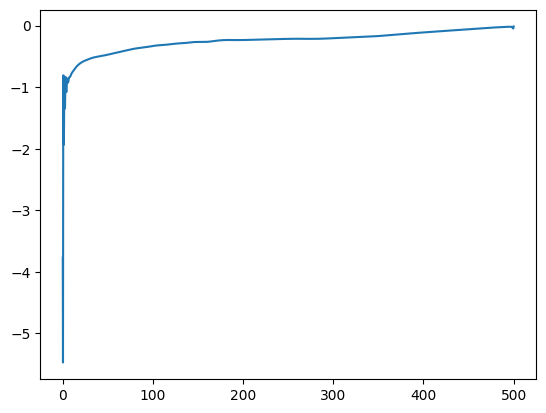

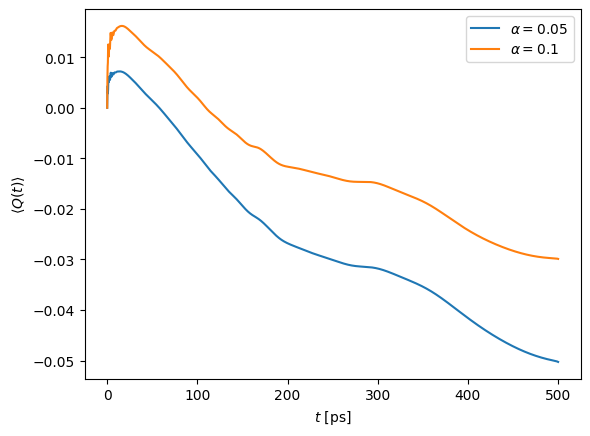

ValueError: x and y must have same first dimension, but have shapes (2001,) and (715,)

 46.2%  132 of  286 [##################----------------------] 06:06:43

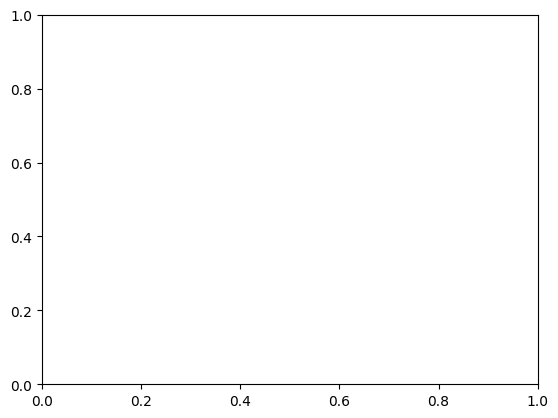

 46.2%  132 of  286 [##################----------------------] 07:20:44

In [ ]:
file_name1='results/optimised_longer/dt=0.25ps_eps=-8.0_tcut=50/500ps'.format(tcut)
with open(file_name1,'rb') as f:
    opt_dict_1=dill.load(f)

file_name1='results/zero_control_lowercoupling/dt=0.25_ps=-8.0_tcut=30_alpha=0.05/500ps'
with open(file_name1,'rb') as f:
        control_dict=dill.load(f)
control=control_dict['result'].x

plt.plot(np.linspace(0,500,len(control)),control)
plt.show()
heat=control_dict['log'][-1]['full heats']

t,sx=opt_dict['fidelitygrad']['dynamics'].expectations(op.sigma('x'), real=True)

t_1,sx_1=opt_dict_1['dynamics'].expectations(op.sigma('x'),real=True)

plt.plot(t_1,heat,label=r'$\alpha=0.05$')
plt.plot(t_1,opt_dict_1['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label=r'$\alpha=0.1$')
plt.xlabel(r'$t$ [ps]')
plt.ylabel(r'$\langle Q (t) \rangle$')
plt.legend()
plt.show()

plt.plot(t_1,sx,label=r'$\alpha=0.05$')

plt.plot(t_1,sx_1,label=r'$\alpha=0.1$')

plt.xlabel(r'$t$ [ps]')
plt.ylabel(r'$\langle \sigma_x \rangle$')
plt.legend()
plt.show()

 46.2%  132 of  286 [##################----------------------] 01:01:18

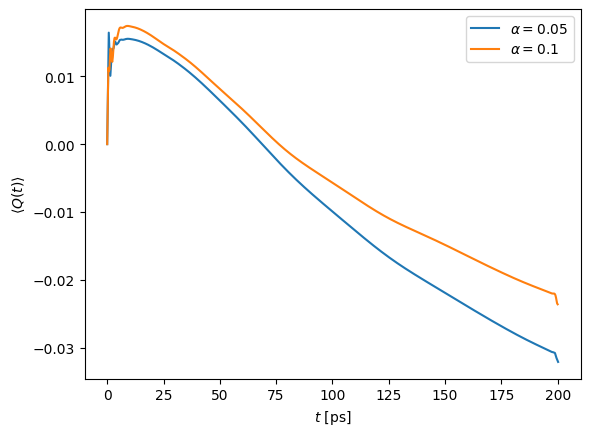

 27.3%   78 of  286 [##########------------------------------] 00:49:54

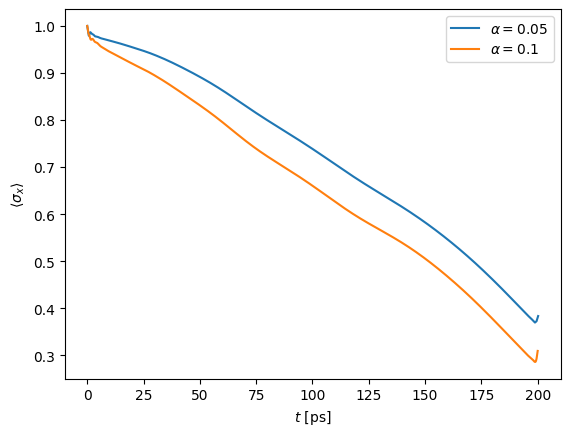

 27.3%   78 of  286 [##########------------------------------] 00:54:57

In [ ]:
file_name1='results/opt_convergence_lowercoupling/dt=0.7ps_eps=-8.0_tcut=60/200ps'.format(tcut)
with open(file_name1,'rb') as f:
    opt_dict_05=dill.load(f)

file_name1='results/optimised_longer/dt=0.25ps_eps=-8.0_tcut=50/200ps'.format(tcut)
with open(file_name1,'rb') as f:
    opt_dict_1=dill.load(f)
t_05,sx_05=opt_dict_05['dynamics'].expectations(op.sigma('x'),real=True)
t_05,sy_05=opt_dict_05['dynamics'].expectations(op.sigma('y'),real=True)
t_05,sz_05=opt_dict_05['dynamics'].expectations(op.sigma('z'),real=True)
t_1,sx_1=opt_dict_1['dynamics'].expectations(op.sigma('x'),real=True)
t_1,sy_1=opt_dict_1['dynamics'].expectations(op.sigma('y'),real=True)
t_1,sz_1=opt_dict_1['dynamics'].expectations(op.sigma('z'),real=True)

plt.plot(t_05,opt_dict_05['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label=r'$\alpha=0.05$')
plt.plot(t_1,opt_dict_1['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label=r'$\alpha=0.1$')
plt.xlabel(r'$t$ [ps]')
plt.ylabel(r'$\langle Q (t) \rangle$')
plt.legend()
plt.show()

plt.plot(t_05,sx_05,label=r'$\alpha=0.05$')
#plt.plot(t_05,sy_05,label=r'$\alpha=0.05$')
#plt.plot(t_05,sz_05,label=r'$\alpha=0.05$')
plt.plot(t_1,sx_1,label=r'$\alpha=0.1$')
#plt.plot(t_1,sy_1,label=r'$\alpha=0.1$')
#plt.plot(t_1,sz_1,label=r'$\alpha=0.1$')
plt.xlabel(r'$t$ [ps]')
plt.ylabel(r'$\langle \sigma_x \rangle$')
plt.legend()
plt.show()

 46.2%  132 of  286 [##################----------------------] 05:43:59

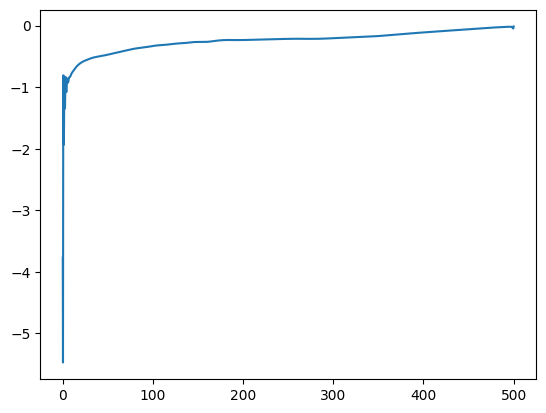

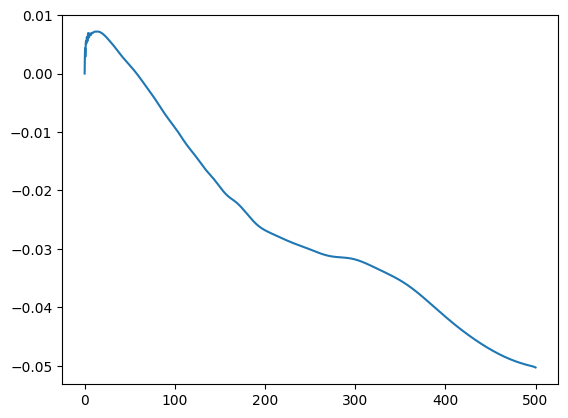

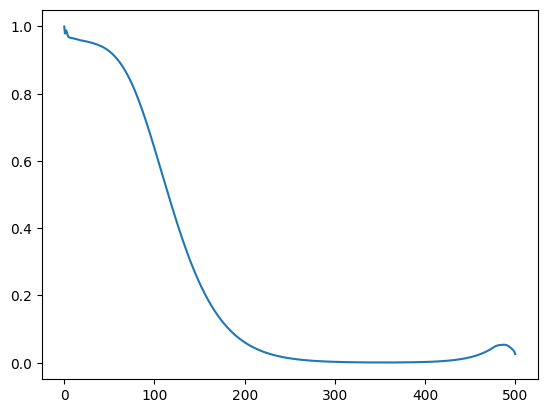

 27.3%   78 of  286 [##########------------------------------] 05:53:13

In [ ]:

file_name1='results/zero_control_lowercoupling/dt=0.25_ps=-8.0_tcut=30_alpha=0.05/500ps'
with open(file_name1,'rb') as f:
        control_dict=dill.load(f)
control=control_dict['result'].x

plt.plot(np.linspace(0,500,len(control)),control)
plt.show()
heat=control_dict['log'][-1]['full heats']
plt.plot(np.linspace(0,500,len(heat)),heat)
plt.show()
t,sx=opt_dict['fidelitygrad']['dynamics'].expectations(op.sigma('x'), real=True)
plt.plot(t,sx)
plt.show()

 50.0%  400 of  800 [####################--------------------] 03:46:31

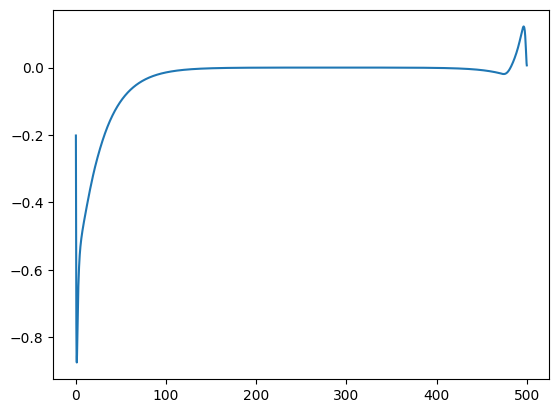

 53.2%  426 of  800 [#####################-------------------] 03:28:23

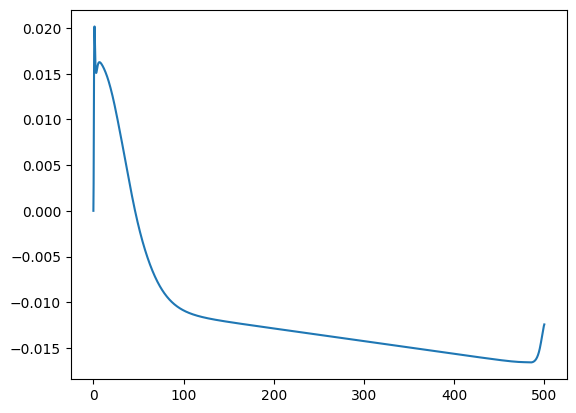

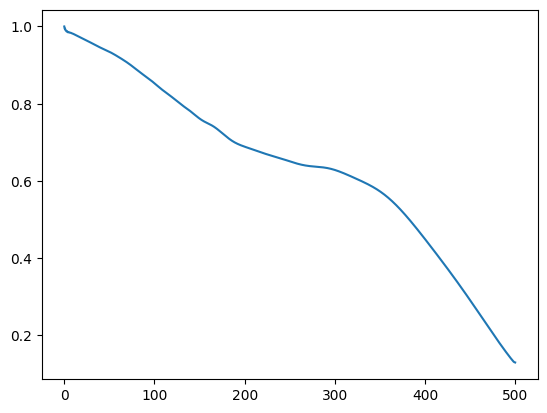

 27.3%   78 of  286 [##########------------------------------] 23:59:17:10:41

In [ ]:
file_name1='results/zero_control_lowercoupling/dt=0.25_ps=-8.0_tcut=30_alpha=0.05_new/500ps'

with open(file_name1,'rb') as f:
        control_dict=dill.load(f)
control=control_dict['result'].x

plt.plot(np.linspace(0,500,len(control)),control)
plt.show()
heat=control_dict['log'][-1]['full heats']
plt.plot(np.linspace(0,500,len(heat)),heat)
plt.show()
t,sx=opt_dict['fidelitygrad']['dynamics'].expectations(op.sigma('x'), real=True)
plt.plot(t,sx)
plt.show()
